In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(patchwork)
    library(future)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

In [2]:
sussman2024 <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT.RDS')
sussman2024

An object of class Seurat 
19327 features across 322559 samples within 7 assays 
Active assay: RNA (19152 features, 2000 variable features)
 6 other assays present: prediction.score.dmg.atlas.lvl_1, prediction.score.dmg.atlas.lvl_2, prediction.score.dmg.atlas.lvl_3, prediction.score.dmg.atlas.lvl_4, prediction.score.dmg.atlas.lvl_4_coarse, prediction.score.dmg.atlas.lvl_5
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [4]:
path_ref <- '/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_scglue_embbeding.rds'
reference <- readRDS(path_ref)
reference

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

In [5]:
reference <- AddMetaData(reference, readRDS('../data/dmg_atlas_final_annotation_v2.rds'))

### Reference mapping

In [ ]:
anchors <- FindTransferAnchors(
  reference = reference,
  query = sussman2024,
  features = rownames(reference[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“930 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 18318 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 81833 anchors

Filtering anchors



`Map Query` functions run separately

In [ ]:
sussman2024 <- TransferData(
  anchorset = anchors, 
  reference = reference,
  query = sussman2024,
  refdata = list(
      dmg.atlas.seuratv4.lvl_1 = 'lvl_1',
      dmg.atlas.seuratv4.lvl_2 = 'lvl_2',
      dmg.atlas.seuratv4.lvl_3 = 'lvl_3',
      dmg.atlas.seuratv4.lvl_4 = 'lvl_4',
      dmg.atlas.seuratv4.lvl_4_coarse = 'lvl_4_coarse',
      dmg.atlas.seuratv4.lvl_5 = 'lvl_5'
  ),
)

In [ ]:
sussman2024 <- IntegrateEmbeddings(
  anchorset = anchors,
  reference = reference,
  query = sussman2024, 
  new.reduction.name = "ref.pca"
)

### UMAP embbeding projection

In [ ]:
sussman2024 <- ProjectUMAP(
  query = sussman2024, 
  query.reduction = "ref.pca", 
  reference = reference, 
  reference.reduction = "pca", 
  reduction.model = "umap"
)

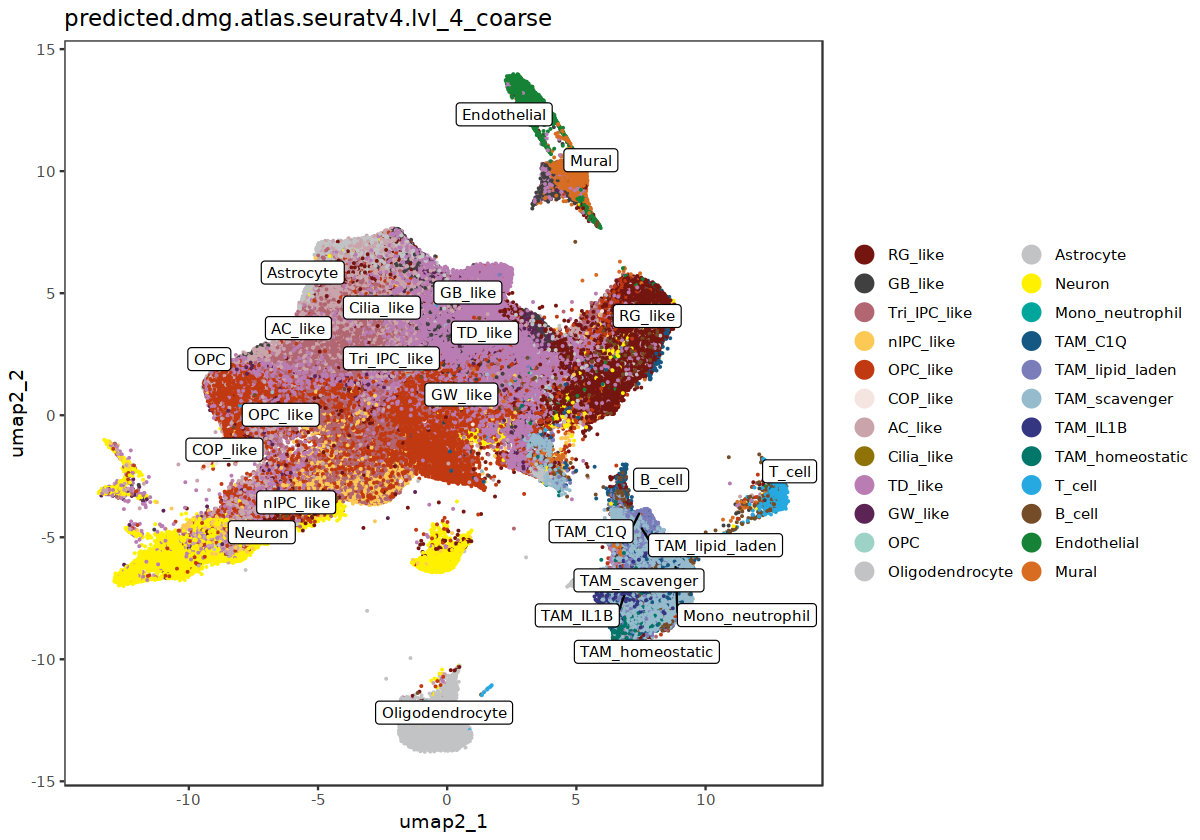

In [24]:
options(repr.plot.height = 7, repr.plot.width = 10)
dittoDimPlot(sussman2024, color.panel = colors,
             reduction.use = "umap", var = "predicted.dmg.atlas.seuratv4.lvl_4_coarse", 
             do.label = T, labels.size = 3, size = 0.5)

In [56]:
saveRDS(sussman2024, '/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT.RDS')